### **Project Overview**

**BNSP Associate Data Scientist Certification Scenario**

> **[Indonesia Version]** Anda adalah Associate Data Scientist di PT Data Analytics Ritel yang bertugas mengembangkan model prediktif untuk memprediksi volume penjualan produk tertentu di masa depan, atau mengklasifikasikan transaksi sebagai penipuan (fraud). Anda diberikan dataset mentah (simulasi) yang mengandung missing value, data kotor, dan outlier. Anda harus membersihkan, memproses, membangun, dan mengevaluasi model akhir.

> **[English Version]**
You are an Associate Data Scientist at PT Data Analytics Ritel. Your task is to develop predictive models to either:
> - Forecast the sales volume of specific products in the future, or
> - Classify transactions as fraudulent (fraud detection)
> You are given a raw (simulated) dataset that contains missing values, dirty data, and outliers. You must clean, process, build, and evaluate the final model.

**Scenario Adjustment**

This project is designed to fulfill the requirements of the original scenario states before.

#### **Dataset & Client Overview**
Our Client:

A fashion boutique owner who sells 8 different brands in a single store. The brands include:
Zara, Uniqlo, H&M, Mango, Banana Republic, Gap, Forever21, and Ann Taylor.

Our Dataset:

A simulated retail transaction dataset containing 2,176 rows of purchase records spanning from 2024 to 2025.

#### **Project Scope**
To align with this scenario, my end-to-end project will cover:
1. Setup & Load Datase || Import libraries, mount Google Drive, load dataset, initial inspection
2. Exploratory Data Analysis (EDA) || Understand data distribution, missing values, outliers, and feature relationships
3. Data Wrangling || Handle missing values, outliers, and inconsistent data types
4. Feature Engineering || Create new features (discount_depth, price_ratio, return_rate, loss metrics, etc.)
5. Data Visualization || Visualize patterns, trends, and relationships (scatter plots, bar charts, heatmaps)
6. Encoding Categorical Variables || One-Hot Encoding for nominal columns, Label Encoding for ordinal columns
7. Modeling || Build regression model (sales forecasting) and classification model (return prediction)
8. Evaluation & Business Recommendations || Assess model performance and provide actionable insights

### **1. Setup and Load Dataset**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/My Drive/Ujian BNSP Kinaya Rafa /fashion_boutique_dataset.xlsx'
df = pd.read_excel(file_path)
df.head()

,product_id,category,brand,season,size,color,original_price,markdown_percentage,current_price,purchase_date,stock_quantity,customer_rating,is_returned,return_reason
0,FB000001,Outerwear,Zara,Spring,XL,Red,196.01,0.0,196.01,2025-07-05,37,3.0,False,NaN
1,FB000002,Tops,Uniqlo,Winter,L,Pink,119.64,0.0,119.64,2025-08-06,2,2.5,False,NaN
2,FB000003,Accessories,Uniqlo,Winter,NaN,Black,33.80,0.0,33.80,2025-08-06,22,4.3,False,NaN
3,FB000004,Shoes,Uniqlo,Spring,XL,Black,75.36,0.0,75.36,2025-07-07,48,2.6,False,NaN
4,FB000005,Tops,Banana Republic,Winter,XL,Black,105.02,0.0,105.02,2025-08-06,10,NaN,False,NaN


### **2. Exploratory Data Analysis (EDA)**

#### EDA - Check Structure Data

In [ ]:
print(df.columns) # Check column names
print(df.shape) # Check dataset shape
print(df.dtypes) # check data types

Index(['product_id', 'category', 'brand', 'season', 'size', 'color',
       'original_price', 'markdown_percentage', 'current_price',
       'purchase_date', 'stock_quantity', 'customer_rating', 'is_returned',
       'return_reason'],
      dtype='object')
(2176, 14)
product_id                     object
category                       object
brand                          object
season                         object
size                           object
color                          object
original_price                float64
markdown_percentage           float64
current_price                 float64
purchase_date          datetime64[ns]
stock_quantity                  int64
customer_rating               float64
is_returned                      bool
return_reason                  object
dtype: object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2176 entries, 0 to 2175
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   product_id           2176 non-null   object        
 1   category             2176 non-null   object        
 2   brand                2176 non-null   object        
 3   season               2176 non-null   object        
 4   size                 1685 non-null   object        
 5   color                2176 non-null   object        
 6   original_price       2176 non-null   float64       
 7   markdown_percentage  2176 non-null   float64       
 8   current_price        2176 non-null   float64       
 9   purchase_date        2176 non-null   datetime64[ns]
 10  stock_quantity       2176 non-null   int64         
 11  customer_rating      1814 non-null   float64       
 12  is_returned          2176 non-null   bool          
 13  return_reason        320 non-null

In [ ]:
df.describe(include='all').T # Check statistical summary

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
product_id,2176,2176,FB002160,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,2176,6,Accessories,402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,2176,8,Zara,313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,2176,4,Summer,575,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,1685,6,XS,301,NaN,NaN,NaN,NaN,NaN,NaN,NaN
color,2176,11,Green,222,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_price,2176.0,NaN,NaN,NaN,97.20034,15.14,57.8725,88.6,127.63,249.98,51.637345
markdown_percentage,2176.0,NaN,NaN,NaN,12.144715,0.0,0.0,0.0,22.425,59.9,18.417786
current_price,2176.0,NaN,NaN,NaN,85.499596,7.29,46.845,74.885,112.865,249.98,50.091354
purchase_date,2176,NaN,NaN,NaN,2025-06-21 23:33:31.764705792,2024-08-06 00:00:00,2025-08-06 00:00:00,2025-08-06 00:00:00,2025-08-06 00:00:00,2025-08-06 00:00:00,NaN


In [ ]:
print(df['category'].unique().tolist())
print(df['brand'].unique().tolist())
print(df['season'].unique().tolist())
print(df['size'].unique().tolist())
print(df['color'].unique().tolist())

['Outerwear', 'Tops', 'Accessories', 'Shoes', 'Bottoms', 'Dresses']
['Zara', 'Uniqlo', 'Banana Republic', 'Mango', 'H&M', 'Ann Taylor', 'Gap', 'Forever21']
['Spring', 'Winter', 'Fall', 'Summer']
['XL', 'L', nan, 'S', 'XXL', 'XS', 'M']
['Red', 'Pink', 'Black', 'White', 'Gray', 'Blue', 'Green', 'Beige', 'Navy', 'Purple', 'Brown']


#### EDA - Check missing value and Duplicate

In [ ]:
df.isnull().sum()

,0
product_id,0
category,0
brand,0
season,0
size,491
color,0
original_price,0
markdown_percentage,0
current_price,0
purchase_date,0


In [ ]:
df.duplicated().sum()

np.int64(0)

- There are no duplicates in this dataset.
- There are missing value in several columns, including size, customer_rating, and return_reason
- For return_reason, we will fill missing value with 'Other'
- For customer_rating and size, which contain approximately 20% missing data, we cannot simply drop them. Instead, we will handle them using appropriate imputation strategies.
- Why? Because we can calculate the median customer_rating for the same product category or brand. This median value is credible enough to use for imputing our missing data.
- For the size column, we can use the mode to fill in the missing values.

#### EDA - Numerical Features Distribution

Index(['original_price', 'markdown_percentage', 'current_price',
       'stock_quantity', 'customer_rating'],
      dtype='object')


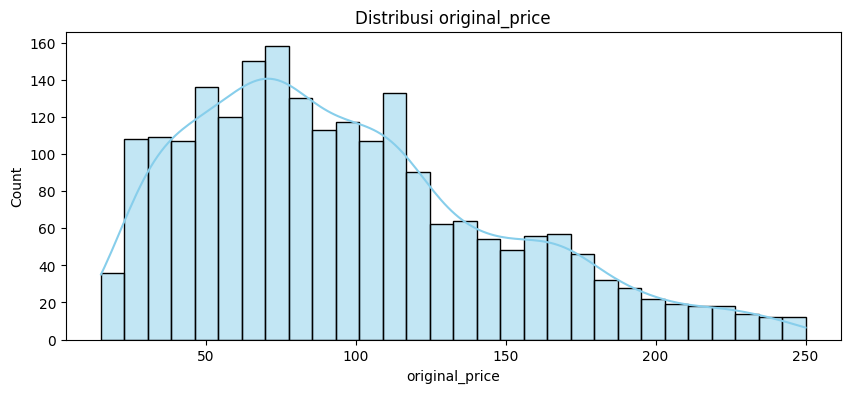

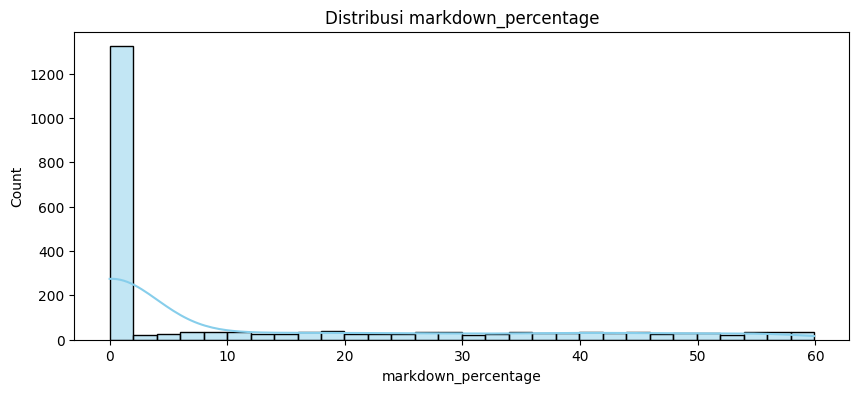

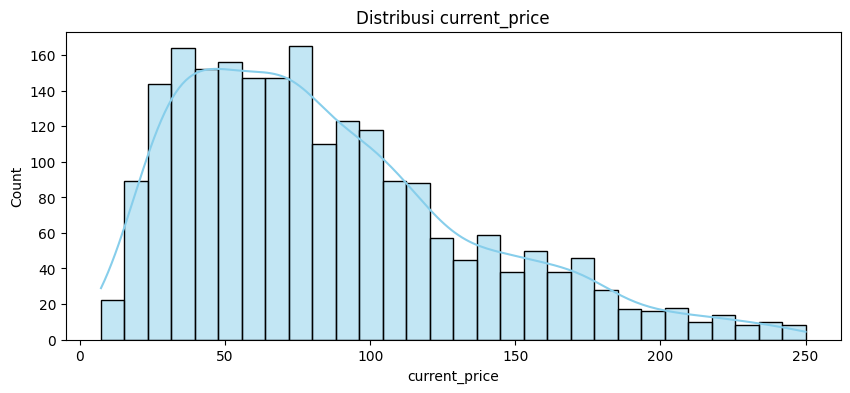

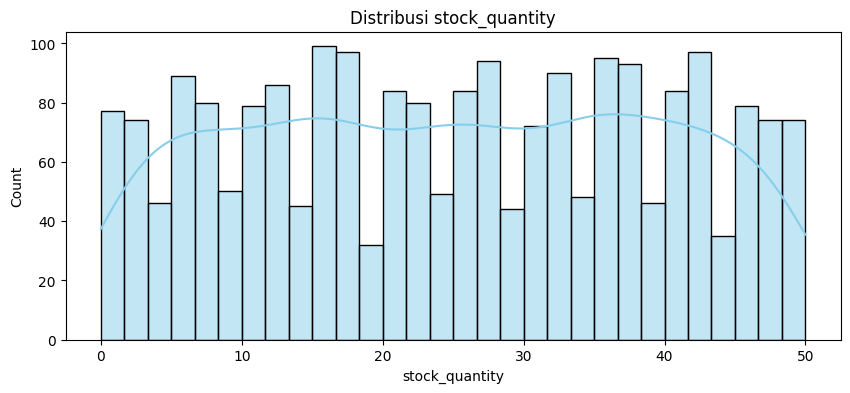

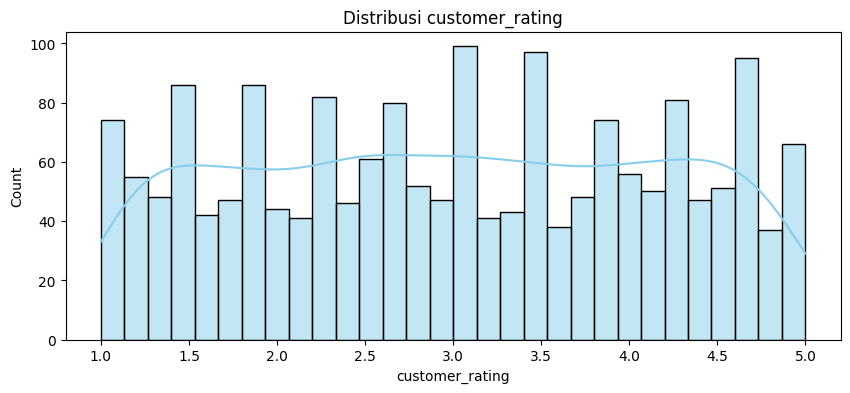

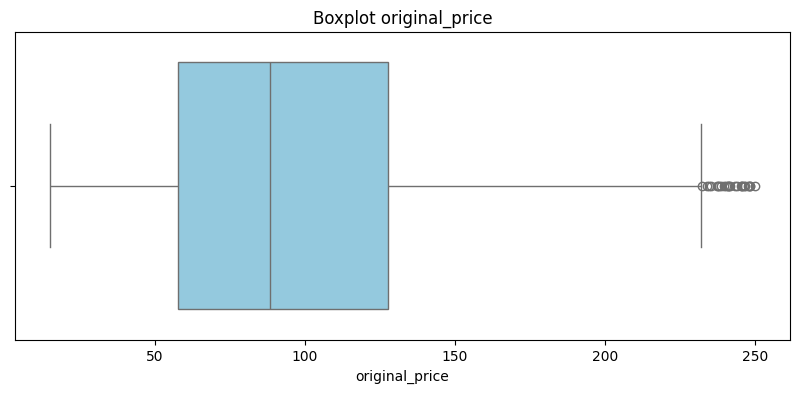

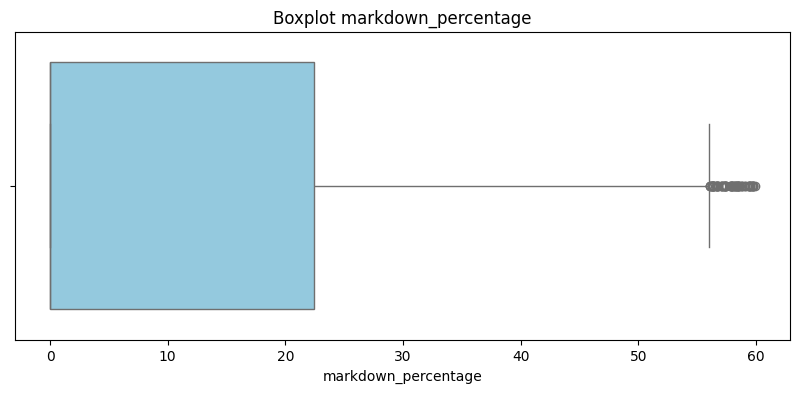

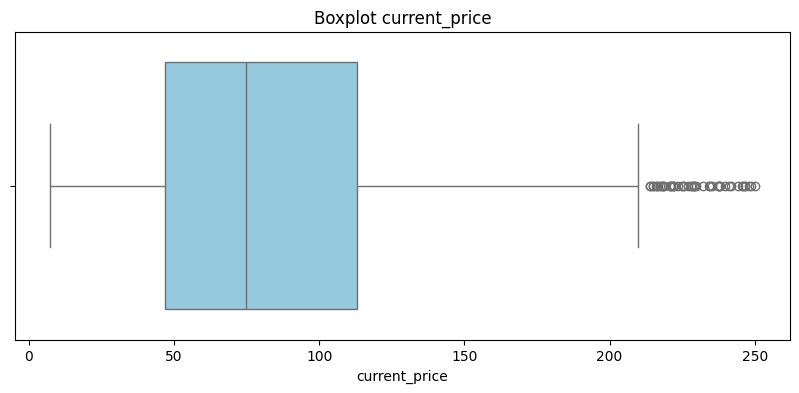

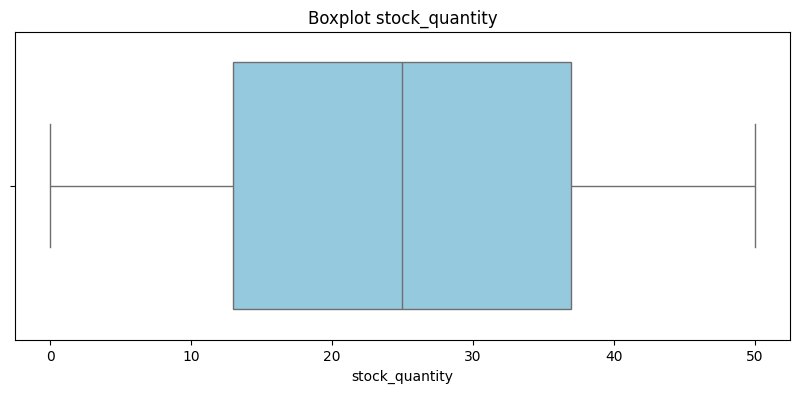

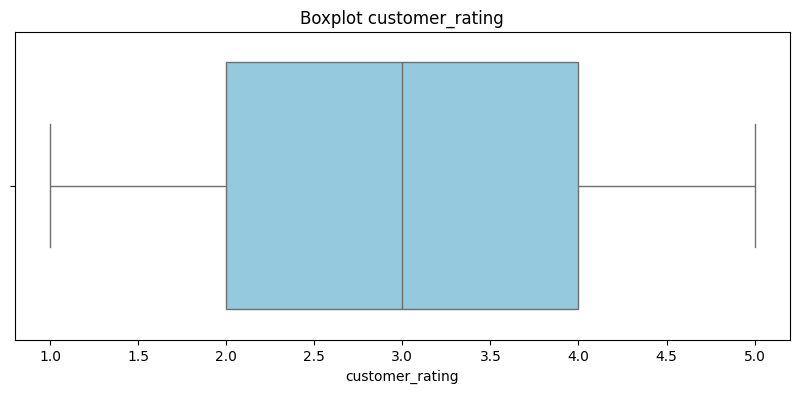

In [ ]:
# Create Histogram
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numeric_cols)
for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    plt.title(f'Distribusi {col}')
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
plt.show()

# Create Boxplot to check outlier
for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    plt.title(f'Boxplot {col}')
    sns.boxplot(x=df[col], color='skyblue')
plt.show()

- The features original_price, markdown_percentage, and current_price contain several outliers that require further investigation

#### EDA - Categorical Features Distribution

Index(['product_id', 'category', 'brand', 'season', 'size', 'color',
       'purchase_date', 'is_returned', 'return_reason'],
      dtype='object')


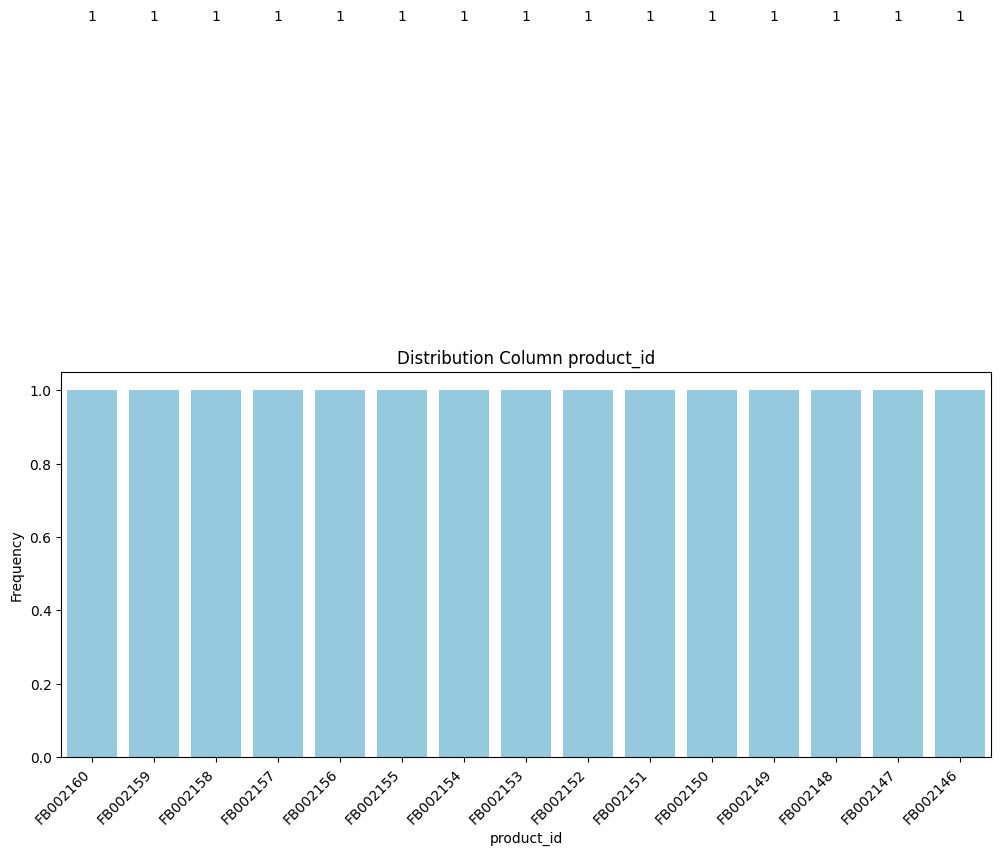

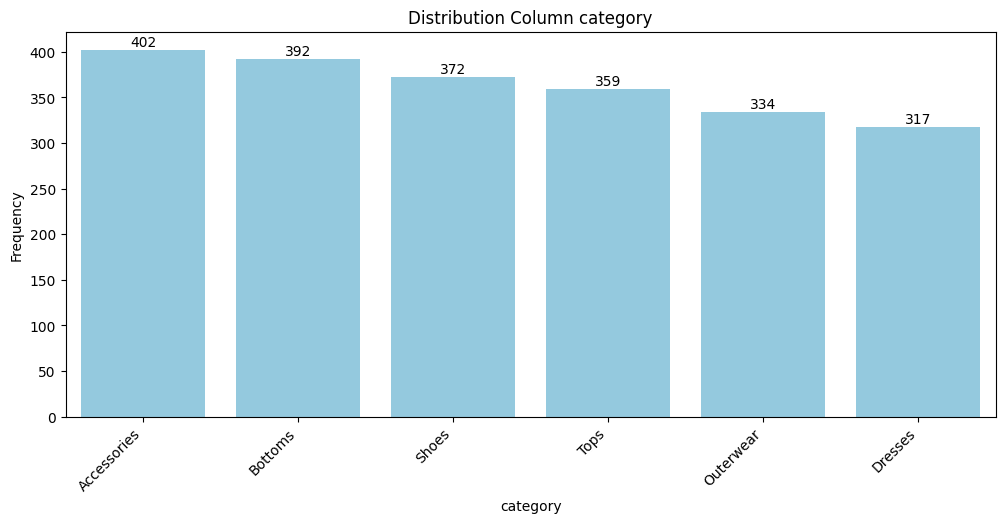

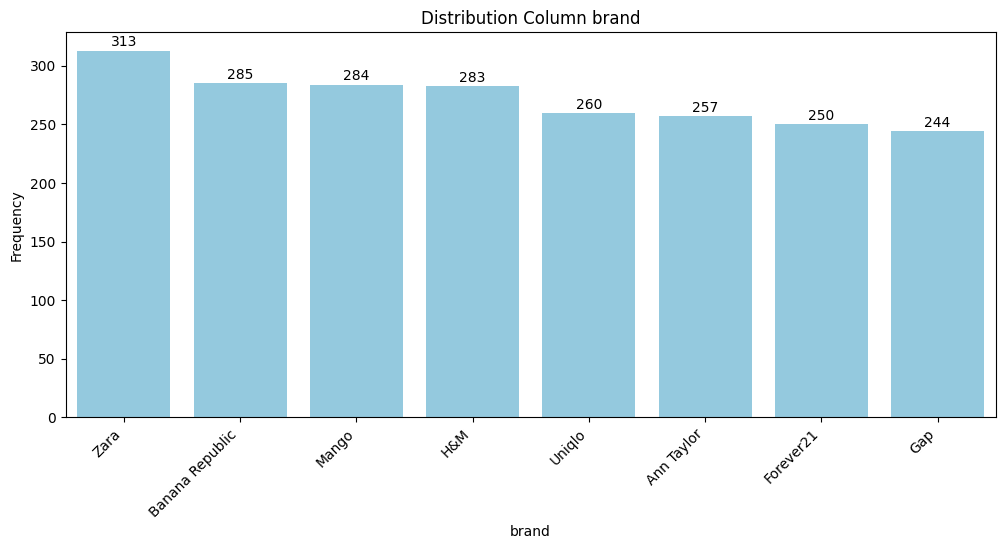

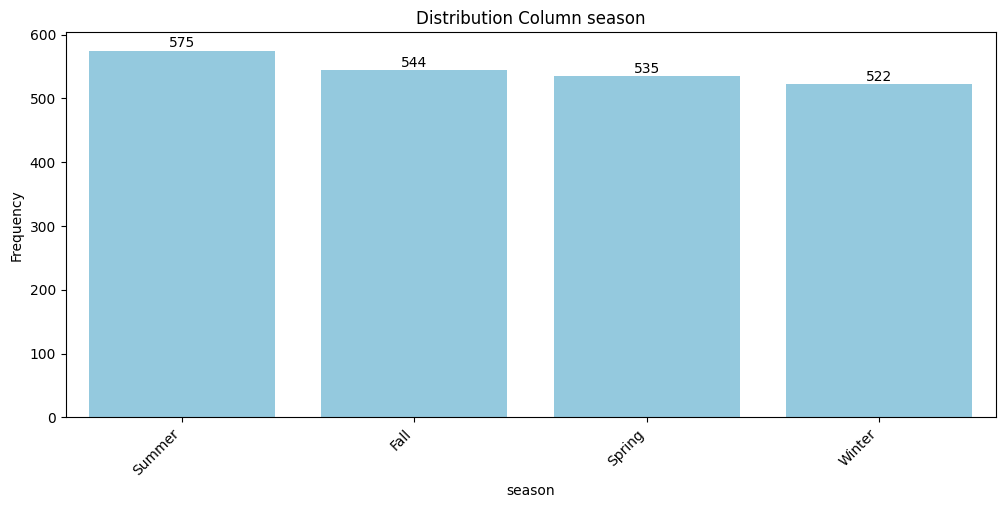

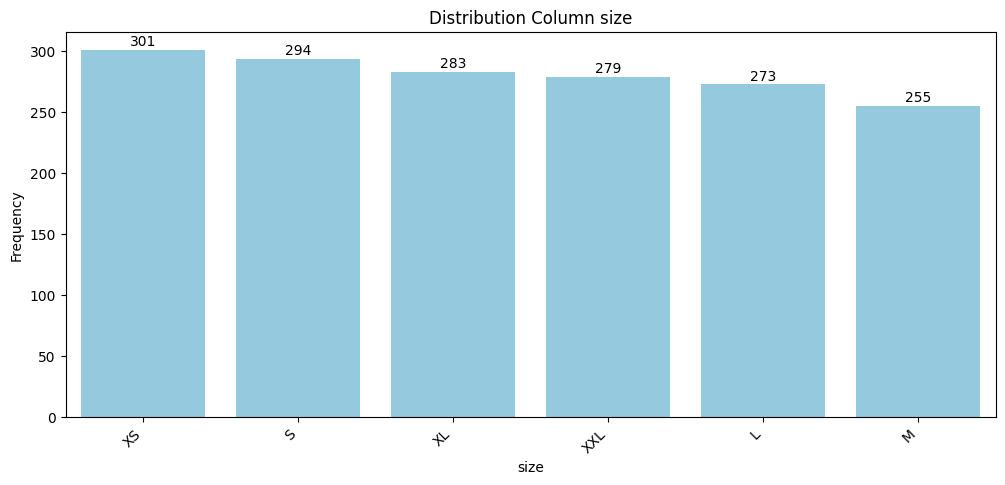

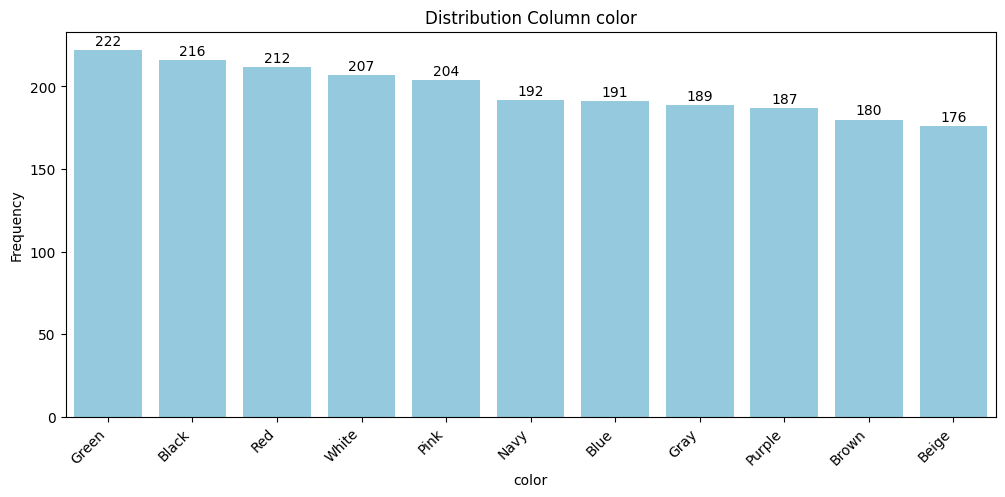

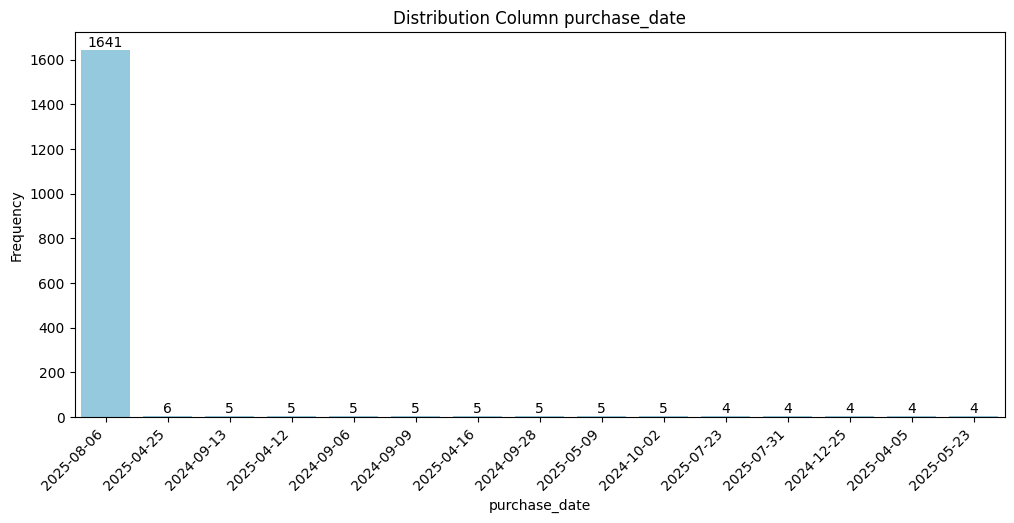

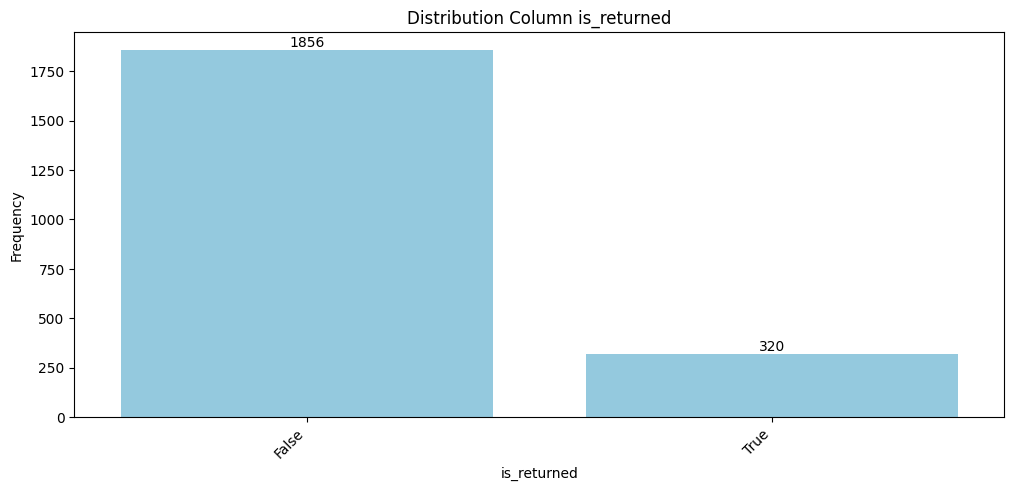

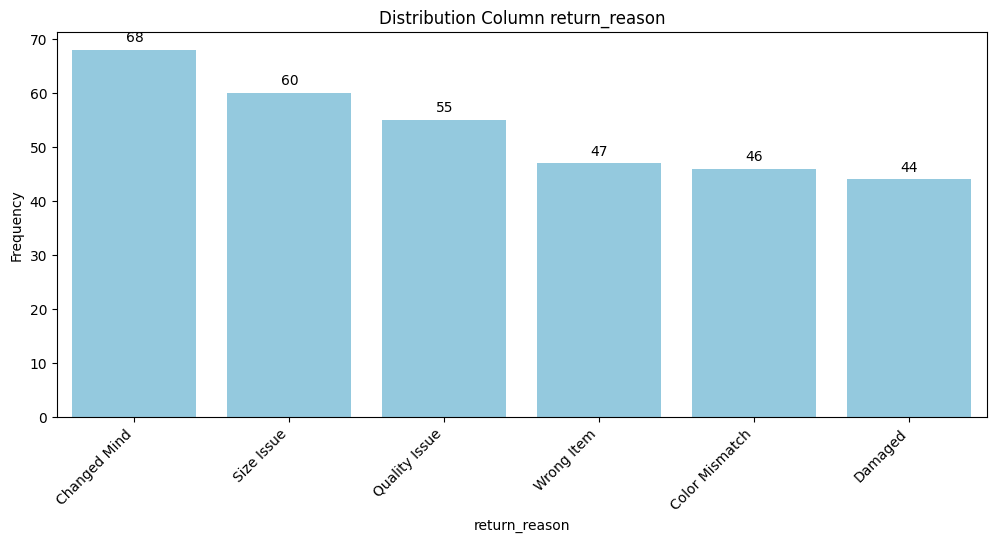

In [ ]:
# Create Bar chart
cat_cols = df.select_dtypes(exclude=['int64', 'float64']).columns
print(cat_cols)
for col in cat_cols:
    plt.figure(figsize=(12, 5))
    value_counts = df[col].value_counts()
    sns.barplot(x=value_counts.head(15).index, y=value_counts.head(15).values, color='skyblue')
    plt.title(f'Distribution Column {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    # add value per label
    for i, v in enumerate(value_counts.head(15).values):
        plt.text(i, v + 1, str(v), ha='center', va='bottom')
plt.show()

#### EDA - Correlation Analysis

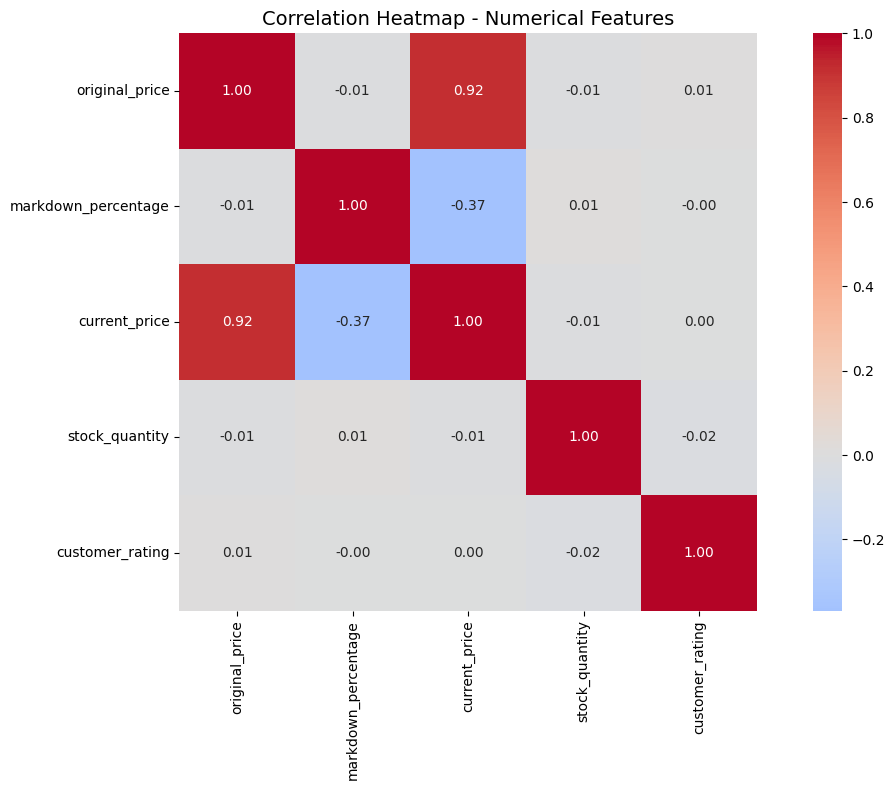

In [ ]:
# Create Heatmap
numeric_for_corr = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_for_corr].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0)
plt.title('Correlation Heatmap - Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

As we can see, our current dataset does not have many columns with strong correlations between them.
- There is a strong correlation (0.92) between original_price and current_price. The correlation between current_price and markdown_percentage is -0.32.
- Therefore, I suggest performing feature engineering to maximize our dataset's potential by creating new columns that may have stronger correlations with the target variable.

### **3. Data Wrangling**

#### Data Wrangling - Handle Missing Value

In [ ]:
# fill missing value in return_reason using 'Other'
df['return_reason'].fillna('Other', inplace=True)
# Fill missing_value in customer_rating using Median
df['customer_rating'].fillna(df.groupby('category')['customer_rating'].transform('median'), inplace=True)
# Fill missing_value in size using Mode
df['size'].fillna(df['size'].mode()[0], inplace=True)

In [ ]:
df.isnull().sum()

,0
product_id,0
category,0
brand,0
season,0
size,0
color,0
original_price,0
markdown_percentage,0
current_price,0
purchase_date,0


#### Data Wrangling - Handle Outlier

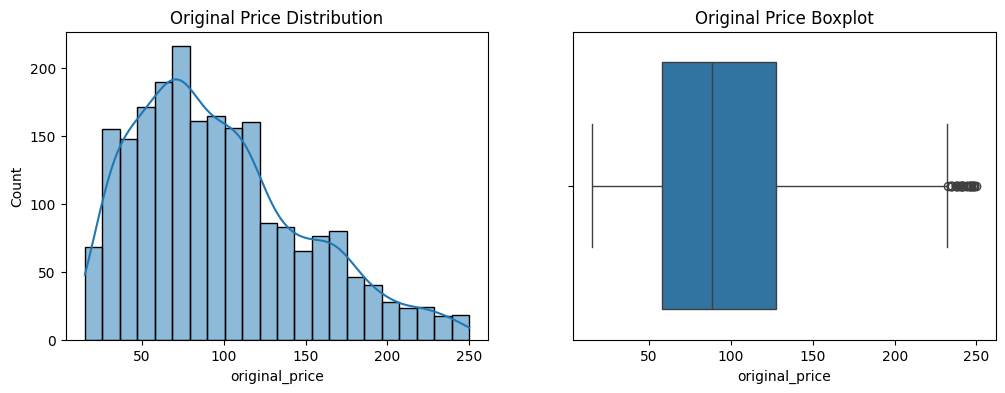

Skewness = 0.7224931303313704


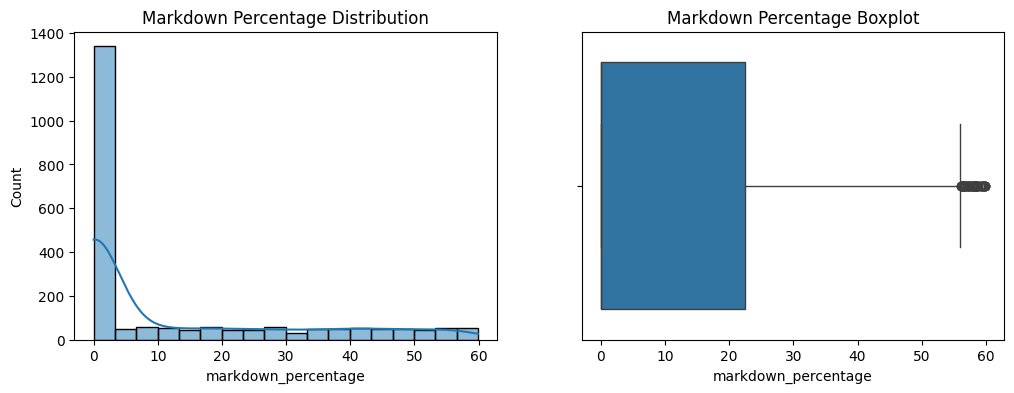

Skewness = 1.257211175752181


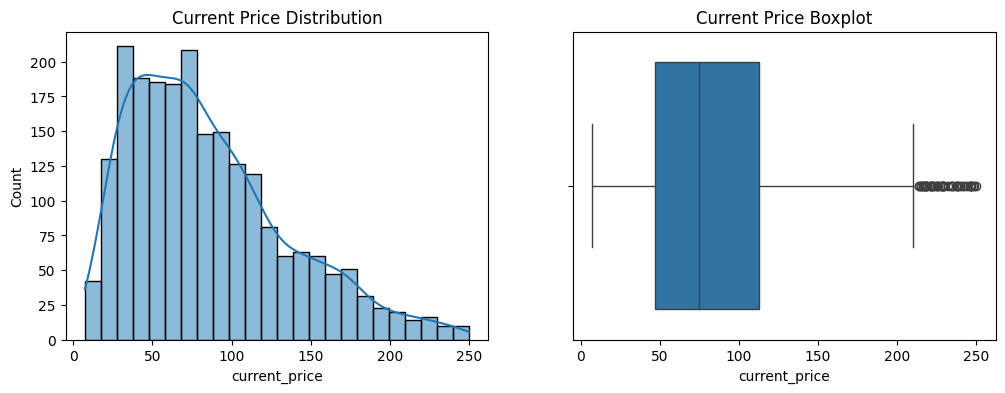

Skewness = 0.8933632616165004

Number of Outliers in original_price: 26
Outlier values: 232.50, 234.14, 234.63, 235.33, 237.53, 237.65, 238.11, 238.89, 239.65, 240.32, 241.09, 241.22, 241.37, 241.81, 243.56, 244.13, 245.31, 245.75, 245.87, 246.49, 246.65, 247.90, 248.05, 248.41, 248.58, 249.98

Number of Outliers in markdown_percentage: 30
Outlier values: 56.10, 56.30, 56.40, 56.50, 56.60, 56.70, 56.80, 57.00, 57.10, 57.30, 57.40, 57.50, 57.80, 57.90, 58.00, 58.10, 58.20, 58.30, 58.40, 58.50, 58.60, 58.70, 58.80, 59.10, 59.30, 59.40, 59.50, 59.70, 59.80, 59.90

Number of Outliers in current_price: 48
Outlier values: 213.94, 213.98, 215.06, 215.10, 215.93, 216.26, 216.73, 217.34, 218.06, 218.41, 218.42, 218.64, 220.71, 220.99, 221.33, 221.94, 222.01, 222.26, 223.53, 225.01, 225.21, 225.64, 226.99, 227.92, 228.46, 228.94, 229.04, 229.17, 229.80, 232.19, 234.14, 234.63, 235.33, 237.24, 237.65, 237.70, 238.11, 239.65, 241.09, 241.81, 244.13, 245.75, 245.87, 246.49, 246.65, 248.05, 248.58, 

In [ ]:
# 1. Further investigation for features 'original_price' before handling outlier
# Check distribution original_price
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df['original_price'], kde=True)
plt.title('Original Price Distribution')
plt.subplot(1,2,2)
sns.boxplot(x=df['original_price'])
plt.title('Original Price Boxplot')
plt.show()
print(f"Skewness = {df['original_price'].skew()}")

# 2. Further investigation for features 'markdown_percentage' before handling outlier
# Check distribution markdown_percentage
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df['markdown_percentage'], kde=True)
plt.title('Markdown Percentage Distribution')
plt.subplot(1,2,2)
sns.boxplot(x=df['markdown_percentage'])
plt.title('Markdown Percentage Boxplot')
plt.show()
print(f"Skewness = {df['markdown_percentage'].skew()}")

# 3. Further investigation for features 'current_price' before handling outlier
# Check distribution current_price
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df['current_price'], kde=True)
plt.title('Current Price Distribution')
plt.subplot(1,2,2)
sns.boxplot(x=df['current_price'])
plt.title('Current Price Boxplot')
plt.show()
print(f"Skewness = {df['current_price'].skew()}")


# check outlier each column
def check_outlier(df, col):
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - (1.5 * iqr)
  upper_bound = q3 + (1.5 * iqr)
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

  if len(outliers) > 0:
    outlier_values = sorted(outliers[col].unique())
    print(f"Number of Outliers in {col}: {len(outlier_values)}")
    print(f"Outlier values: {', '.join([f'{x:.2f}' for x in outlier_values])}")
  else:
    print(f"No outliers found in {col}")

print("\n" + "="*40)
check_outlier(df, 'original_price')
print("\n" + "="*40)
check_outlier(df, 'markdown_percentage')
print("\n" + "="*40)
check_outlier(df, 'current_price')

- There are only minor differences within the outlier, we don't need to handle the outlier (Like capping or transformation log)
- The proposed model will likely be a tree based model, so there's no need to handle the outliers, as tree based model are more robust

### **4. Feature Engineering**

As fashion interest continues to rise, understanding customer purchasing patterns becomes increasingly important. By integrating pricing, seasonality, and inventory features, we can better analyze what drives sales volume and how discounts affect brand equity, ultimately helping the boutique optimize inventory and pricing strategies.

#### Feature Engineering - Price Features

In [ ]:
# 1. Create discount_depth
df['discount_depth'] = df['original_price'] - df['current_price']
# categorize discount_depth
def categorize_discount_pct(pct):
    if pct <= 0:
        return 'No Discount'
    elif pct <= 0.15:      # 1-15% discount
        return 'Low Discount'
    elif pct <= 0.35:      # 16-35% discount
        return 'Medium Discount'
    else:                  # >35% discount
        return 'High Discount'

df['discount_depth_category'] = df['discount_depth'].apply(categorize_discount_pct)

# 2. Create price_ratio
df['price_ratio'] = df['current_price'] / df['original_price']
# categorize price_ratio
def categorize_price_ratio(ratio):
    if ratio == 1:
      return 'Full Price'
    elif ratio >= 0.8:
      return 'Promotional Pricing'
    elif ratio >= 0.65:
      return 'Clearance / Seasonal Sales'
    else:
      return 'Liquidation / Salvage'

df['price_ratio_category'] = df['price_ratio'].apply(categorize_price_ratio)

# 3. Create is_discounted
df['is_discounted'] = df['discount_depth'].apply(lambda x: 1 if x > 0 else 0)
# categorize is_discounted
df['is_discounted_category'] = df['is_discounted'].apply(lambda x: 'Discounted' if x == 1 else 'Not Discounted')

print(df[['discount_depth', 'discount_depth_category', 'price_ratio', 'price_ratio_category' ,'is_discounted']].head(10))

   discount_depth discount_depth_category  price_ratio  \
0            0.00             No Discount     1.000000   
1            0.00             No Discount     1.000000   
2            0.00             No Discount     1.000000   
3            0.00             No Discount     1.000000   
4            0.00             No Discount     1.000000   
5           12.40           High Discount     0.646018   
6           29.34           High Discount     0.454951   
7           20.23           High Discount     0.779028   
8           29.15           High Discount     0.871998   
9           27.08           High Discount     0.890987   

         price_ratio_category  is_discounted  
0                  Full Price              0  
1                  Full Price              0  
2                  Full Price              0  
3                  Full Price              0  
4                  Full Price              0  
5       Liquidation / Salvage              1  
6       Liquidation / Salvage   

- By analyzing discount depth and price ratio, we can determine the brand equity from the customer's perspective.
- These metrics help us define the ideal pricing strategy, as high-end customers might perceive a brand as less exclusive if it is too heavily discounted or becomes too 'mass-market'.
- Consequently, we can observe how price elasticity functions across different brands, identifying which ones can maintain demand at higher prices and which ones rely solely on discounts to drive volume.
- These insights enable us to optimize profitability by renegotiating agreements with brands that cannot keep pace with rapidly changing trends. Furthermore, identifying these patterns helps us navigate our store's dynamic environment to better align our offerings with customer demand.

#### Feature Engineering - Seasonality Features

In [ ]:
# 1. Create is_on_season
df['purchase_date'] = pd.to_datetime(df['purchase_date'])
df['purchase_month'] = df['purchase_date'].dt.month
season_month_map = {
    'Spring': [3, 4, 5],
    'Summer': [6, 7, 8],
    'Fall': [9, 10, 11],
    'Winter': [12, 1, 2]
}

def check_on_season(row):
  product_season = row['season']
  purchase_season = row['purchase_month']
  if product_season in season_month_map:
    return 1 if purchase_season in season_month_map[product_season] else 0
  return 0

df['is_on_season'] = df.apply(check_on_season, axis=1)
print(df[['season', 'purchase_month', 'is_on_season']].head(10))

   season  purchase_month  is_on_season
0  Spring               7             0
1  Winter               8             0
2  Winter               8             0
3  Spring               7             0
4  Winter               8             0
5    Fall               8             0
6  Spring              10             0
7  Winter               8             0
8  Spring               3             1
9    Fall               8             0


The is_on_season analysis reveals that most purchases occur off-season. For example, Winter products are often bought in August (Summer), and Spring products are bought in July or October. This mismatch between purchase timing and product seasonality may drive higher return rates, as customer expectations about fabric thickness or warmth are not met. Based on this insight, the boutique should improve product descriptions and clarify seasonal suitability for off-season buyers.

In [ ]:
# check missing value for all of our missing value
missing_check = df.isnull().sum()
missing_check = missing_check[missing_check > 0]

if missing_check.empty:
    print("No missing values in all columns!")
else:
    print(missing_check)

No missing values in all columns!


### **5. Data Visualization**

#### Data Visualization - Target-Feature Relationship

Volume sales per brand:
             brand  volume_sales_per_brand
0       Ann Taylor                     257
1  Banana Republic                     285
2        Forever21                     250
3              Gap                     244
4              H&M                     283
5            Mango                     284
6           Uniqlo                     260
7             Zara                     313


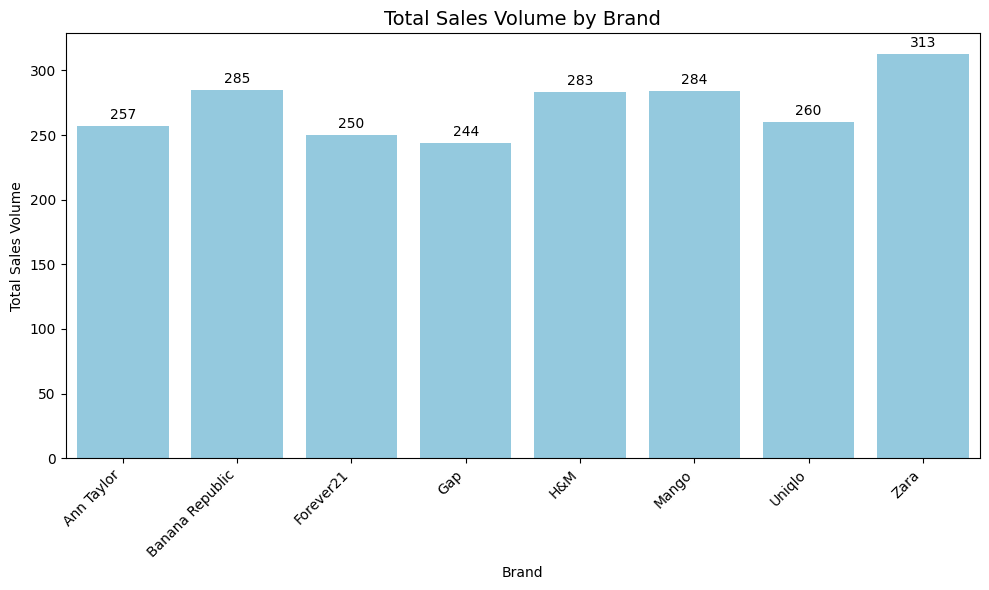

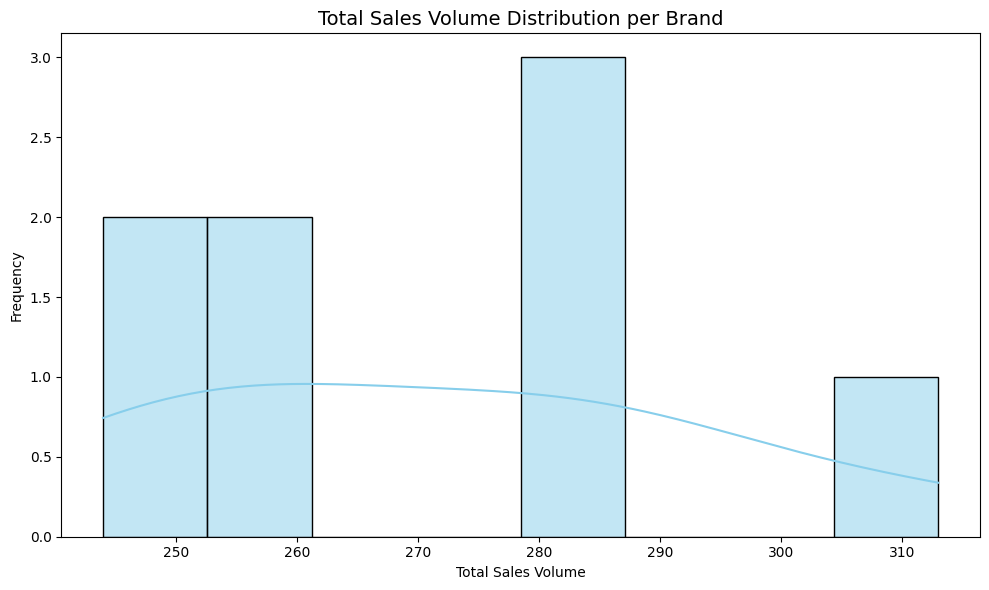

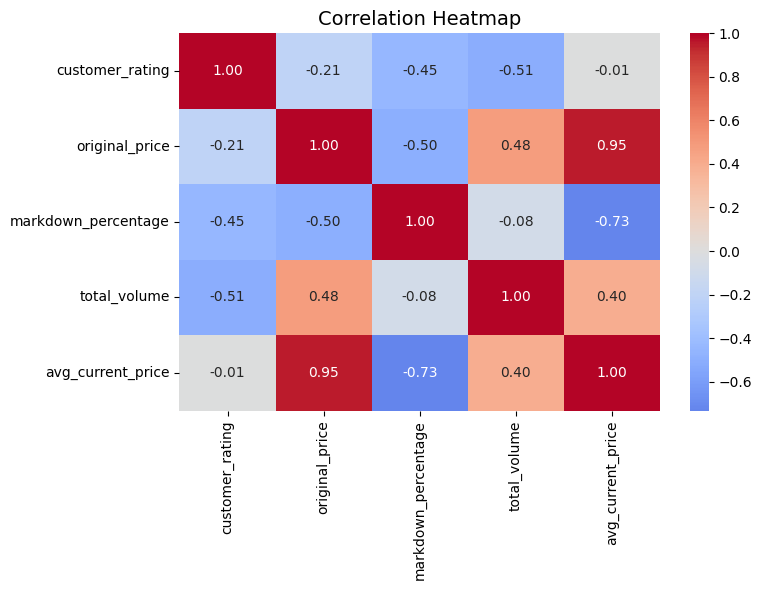

In [ ]:
# for regression, target features = 'volume_sales_per_brand'
# Visualize the volume sales per brand across several features
volume_sales = df.groupby('brand').size().reset_index(name='volume_sales_per_brand')
print(f"Volume sales per brand:\n{volume_sales}")

brand_agg = df.groupby('brand').agg({
    'customer_rating': 'mean',
    'original_price': 'mean',
    'markdown_percentage': 'mean',
    'is_returned': 'mean',
    'product_id': 'count',           # Total Units Sold (Volume)
}).rename(columns={
    'product_id': 'total_volume'
}).reset_index()

brand_agg['avg_current_price'] = brand_agg['original_price'] * (1 - (brand_agg['markdown_percentage']/100))
print("="*40)

# 1. Total Sales Volume by Brand
plt.figure(figsize=(10, 6))
sns.barplot(x='brand', y='total_volume', data=brand_agg, color='skyblue')
plt.title('Total Sales Volume by Brand', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Total Sales Volume')
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(brand_agg['total_volume']):
    plt.text(i, v + 3, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# 2. Total Sales Volume Distribution
plt.figure(figsize=(10, 6))
sns.histplot(brand_agg['total_volume'], bins=8, kde=True, color='skyblue')
plt.title('Total Sales Volume Distribution per Brand', fontsize=14)
plt.xlabel('Total Sales Volume')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 3. Correlation Heatmap
corr_cols = ['customer_rating', 'original_price', 'markdown_percentage','total_volume','avg_current_price']
corr_matrix = brand_agg[corr_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

From the correlation heatmap, the following key relationships were observed:

| Relationship | Correlation | Interpretation |
|--------------|-------------|----------------|
| Total volume ↔ Original price | 0.48 | Products with higher original prices tend to sell more units — indicates brand value matters |
| Original price ↔ Avg current price | 0.95 | Very strong correlation (expected, since current price is derived from original price after discount) |a
| Avg current price ↔ Markdown % | -0.73 | Strong negative correlation — higher markdown leads to lower current price, as expected |
| Total volume ↔ Markdown % | -0.08 | Very weak negative correlation — discounts have almost no impact on sales volume |
| Avg current price ↔ Total volume | -0.01 | No meaningful relationship — price alone does not determine sales volume |

Key Insight: Sales volume is not driven by discounts or low prices. Instead, brand equity and customer loyalty play a much stronger role in purchase decisions. Therefore, the boutique should focus on maintaining brand value rather than relying on aggressive discounting.






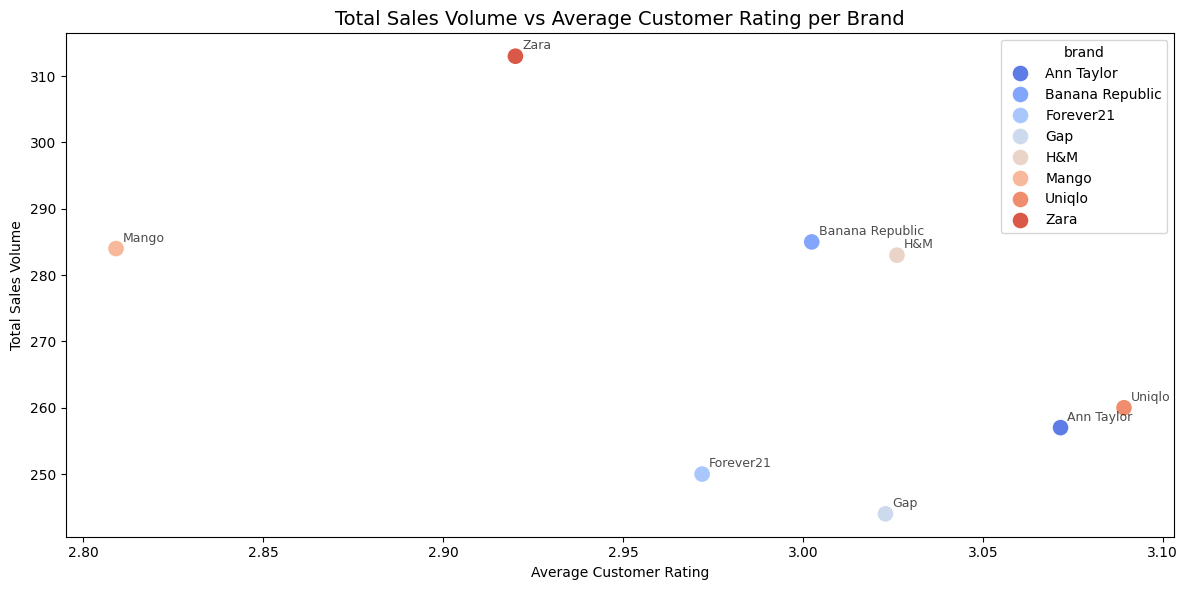

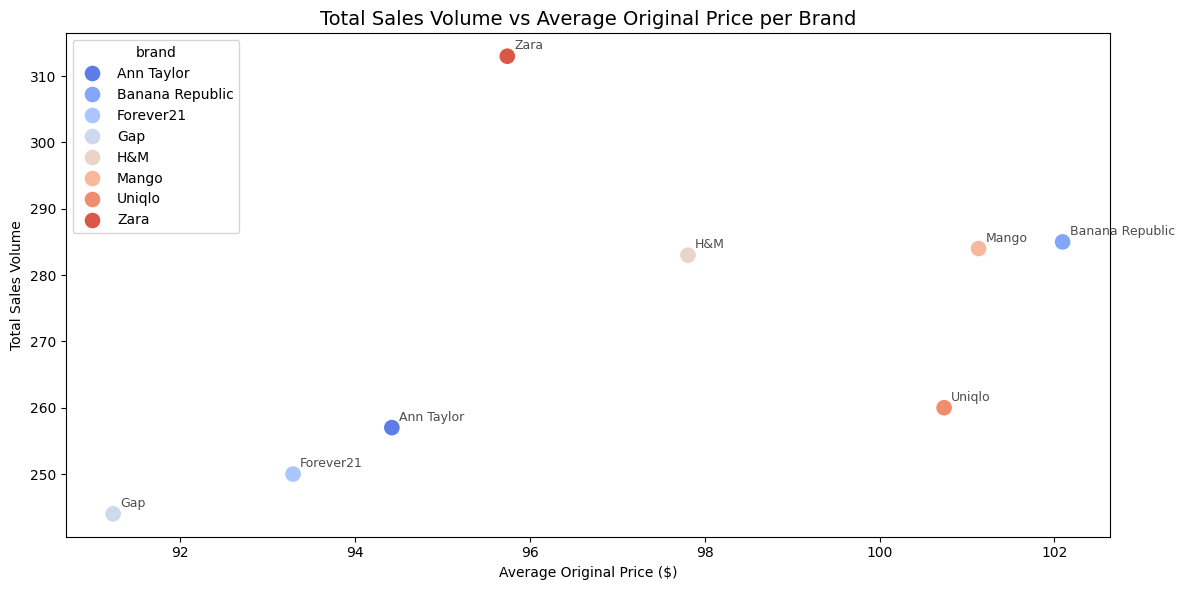

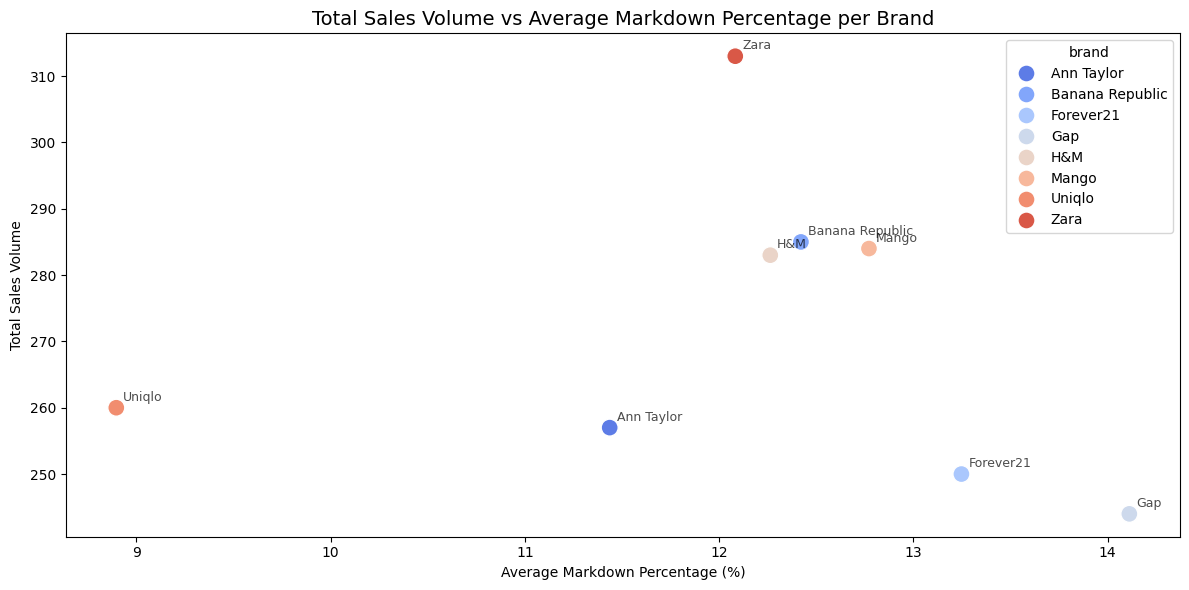

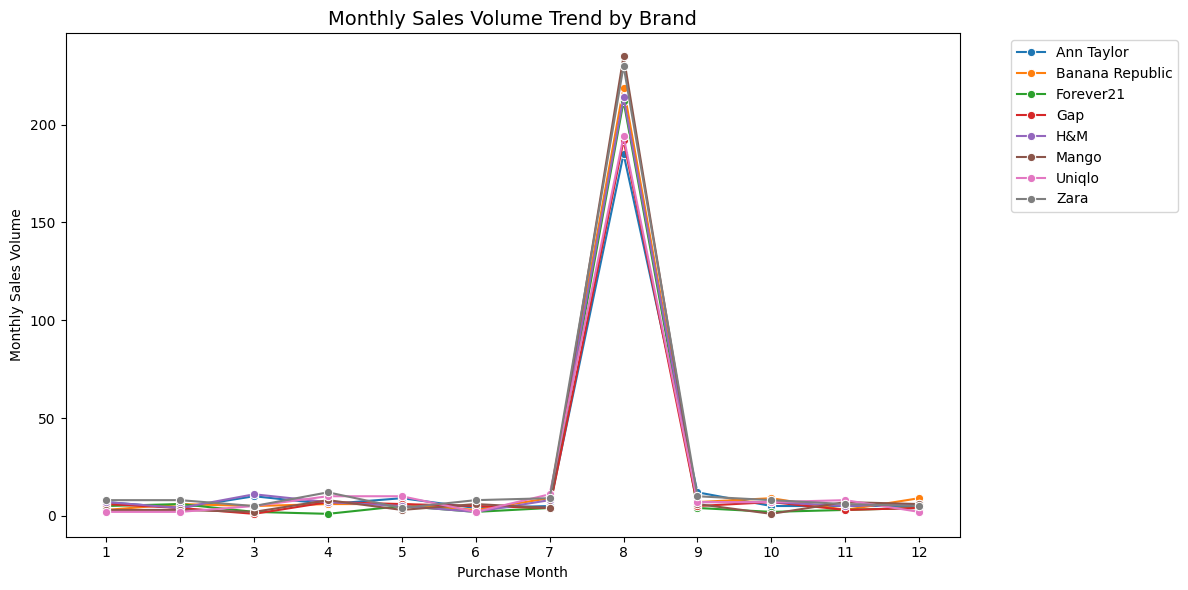

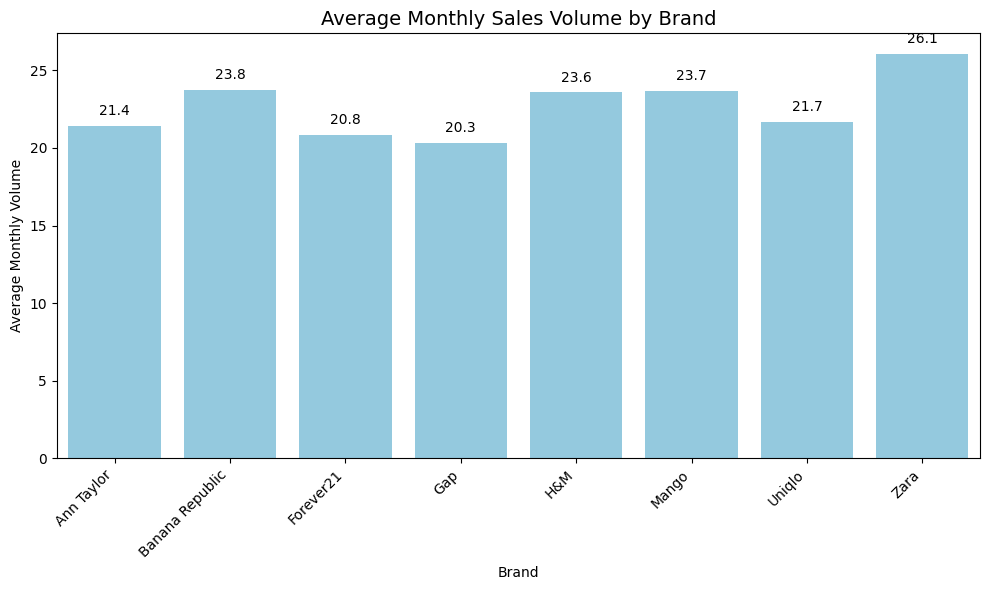

In [ ]:
# Visualization for Regression Model
# 1. Total sales volume vs customer rating per Brand
plt.figure(figsize=(12, 6))
sns.scatterplot(x='customer_rating', y='total_volume', data=brand_agg, s=150, hue='brand', palette='coolwarm')
plt.title('Total Sales Volume vs Average Customer Rating per Brand', fontsize=14)
plt.xlabel('Average Customer Rating')
plt.ylabel('Total Sales Volume')
for i, row in brand_agg.iterrows():
    plt.annotate(row['brand'],
                 xy=(row['customer_rating'], row['total_volume']),
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=9, alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Total sales volume vs Original Price per Brand
plt.figure(figsize=(12, 6))
sns.scatterplot(x='original_price', y='total_volume', data=brand_agg, s=150, hue='brand', palette='coolwarm')
plt.title('Total Sales Volume vs Average Original Price per Brand', fontsize=14)
plt.xlabel('Average Original Price ($)')
plt.ylabel('Total Sales Volume')
for i, row in brand_agg.iterrows():
    plt.annotate(row['brand'],
                 xy=(row['original_price'], row['total_volume']),
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=9, alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Total sales volume vs Markdown Percentage per Brand
plt.figure(figsize=(12, 6))
sns.scatterplot(x='markdown_percentage', y='total_volume', data=brand_agg, s=150, hue='brand', palette='coolwarm')
plt.title('Total Sales Volume vs Average Markdown Percentage per Brand', fontsize=14)
plt.xlabel('Average Markdown Percentage (%)')
plt.ylabel('Total Sales Volume')
for i, row in brand_agg.iterrows():
    plt.annotate(row['brand'],
                 xy=(row['markdown_percentage'], row['total_volume']),
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=9, alpha=0.7)
plt.tight_layout()
plt.show()


# 5. Monthly Sales Volume Trend
monthly_sales = df.groupby(['brand', 'purchase_month']).size().reset_index(name='monthly_volume')
plt.figure(figsize=(12, 6))
sns.lineplot(x='purchase_month', y='monthly_volume', hue='brand', data=monthly_sales, marker='o')
plt.title('Monthly Sales Volume Trend by Brand', fontsize=14)
plt.xlabel('Purchase Month')
plt.ylabel('Monthly Sales Volume')
plt.xticks(range(1, 13))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 6. Average Monthly Volume by Brand
avg_monthly = monthly_sales.groupby('brand')['monthly_volume'].mean().reset_index(name='avg_monthly_volume')
plt.figure(figsize=(10, 6))
sns.barplot(x='brand', y='avg_monthly_volume', data=avg_monthly, color='skyblue')
plt.title('Average Monthly Sales Volume by Brand', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Average Monthly Volume')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(avg_monthly['avg_monthly_volume']):
    plt.text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

1. Total Sales Volume vs Average Customer Rating

Uniqlo and Ann Taylor have high average customer ratings (3.10-3.15) but relatively low sales volumes (260-270 units). In contrast, H&M achieves higher sales (280-290 units) with lower ratings (3.00-3.05). Gap requires improvement, as it has a similar rating to H&M but sales volume below 250 units.

Insight: High customer ratings do not guarantee high sales volume. Brand loyalty and other factors play a stronger role.

2. Total Sales Volume vs Average Original Price

Zara leads with the highest sales volume (over 310 units) at a competitive average original price of $96. Brands priced $100-102 achieve 280-290 units, while Uniqlo only reaches 260 units despite a similar price point.

Insight: Zara has found a pricing sweet spot, competitive pricing drives volume without excessive discounting.

3. Total Sales Volume vs Average Markdown Percentage

Gap has the highest average markdown (over 14%) but still struggles with sales below 250 units. Forever21 faces a similar issue (13-14% markdown, ~250 units). Meanwhile, Zara achieves 310 units with only 12-13% markdown, and Uniqlo reaches 260 units with just 9% markdown.

Insight: High discounts do not guarantee high sales. Brands with strong brand equity (Zara, Uniqlo) rely less on markdowns to drive volume.

4. Monthly Sales Trend
- Monthly sales are quite uneven, with a significant spike in Month 8 where sales exceed 200+ units across multiple brands simultaneously. This indicates a seasonal peak in purchasing activity.

Insight: August is a critical peak season. The boutique should plan inventory, staffing, and promotions around this period.

8. Average Monthly Sales Limitation
- The average monthly sales chart is not fully representative due to the significant spike in Month 8. Calculating the average across all months may be misleading, as the high volume in Month 8 skews the overall figure.

Insight: Use median or analyze pre- and post-peak separately for more accurate monthly comparisons.



#### **KEY TAKEAWAYS**

1. **Healthy Baseline:** Return rates are stable at 12-20% with 85.3% successful transactions, reflecting healthy retail conditions.

2. **Size & Fit Alert:** Size L (18%) and XL (16%) have the highest return rates. Action: Revise size chart or add a 'True to Size' feature.

3. **Seasonal Risk & Clearance Risk:** Summer (17%) and Clearance items (21%) are vulnerable due to fit sensitivity and buyer's remorse. Action: Improve product descriptions and sizing guides for seasonal and clearance items.


4. **Data Anomalies:**
Medium Discount (75%), which Indicates possible data error, requires verification.


#### Data Visualization - Additional

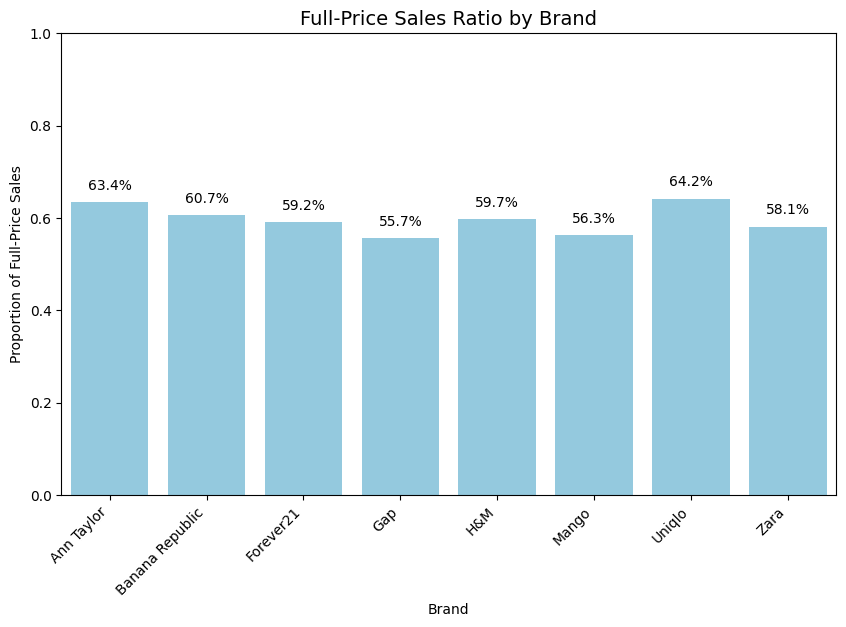

In [ ]:
# Additional - Lost Risk Analysis
# Full-Price vs Discounted Sales Ratio
df['is_full_price'] = (df['markdown_percentage'] == 0).astype(int)
full_price_ratio = df.groupby('brand')['is_full_price'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='brand', y='is_full_price', data=full_price_ratio, color='skyblue')
plt.title('Full-Price Sales Ratio by Brand', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Proportion of Full-Price Sales')
plt.ylim(0,1)
for i, v in enumerate(full_price_ratio['is_full_price']):
    plt.text(i, v + 0.02, f'{v:.1%}', ha='center', va='bottom')
plt.xticks(rotation=45, ha='right')
plt.show()

- The highest full-price sales ratio is for Uniqlo at 64.2%, followed by Ann Taylor at 63.4%, and Banana Republic at 60.7%. This indicates strong customer loyalty, as customers are willing to buy at full price.
- Although Banana Republic needs to apply markdowns to move inventory and prevent rising warehouse costs, customers will still purchase if the product meets their needs, regardless of discount.




### **6. Encoding Categorical Variables**

In [ ]:
print(cat_cols)

Index(['product_id', 'category', 'brand', 'season', 'size', 'color',
       'purchase_date', 'is_returned', 'return_reason'],
      dtype='object')


In [ ]:
# Encoding will be applied to all categorical columns except product_id
# OHE for brand, category, color, and return_reason
# Custom label encoding for season and size

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
label_encoder = LabelEncoder()
df_encode = df.copy()

# OHE
df_encode = pd.get_dummies(df_encode, columns=['brand', 'category', 'color','return_reason'])
# Label Encoding
season_map = {'Spring':1, 'Summer':2, 'Fall':3, 'Winter':4}
df_encode['season'] = df_encode['season'].map(season_map)
size_map = {'XS':1, 'S':2, 'M':3, 'L':4, 'XL':5, 'XXL':6}
df_encode['size'] = df_encode['size'].map(size_map)

In [ ]:
print(df_encode.shape)
df_encode.columns

(2176, 50)


Index(['product_id', 'season', 'size', 'original_price', 'markdown_percentage',
       'current_price', 'purchase_date', 'stock_quantity', 'customer_rating',
       'is_returned', 'discount_depth', 'discount_depth_category',
       'price_ratio', 'price_ratio_category', 'is_discounted',
       'is_discounted_category', 'purchase_month', 'is_on_season',
       'brand_Ann Taylor', 'brand_Banana Republic', 'brand_Forever21',
       'brand_Gap', 'brand_H&M', 'brand_Mango', 'brand_Uniqlo', 'brand_Zara',
       'category_Accessories', 'category_Bottoms', 'category_Dresses',
       'category_Outerwear', 'category_Shoes', 'category_Tops', 'color_Beige',
       'color_Black', 'color_Blue', 'color_Brown', 'color_Gray', 'color_Green',
       'color_Navy', 'color_Pink', 'color_Purple', 'color_Red', 'color_White',
       'return_reason_Changed Mind', 'return_reason_Color Mismatch',
       'return_reason_Damaged', 'return_reason_Other',
       'return_reason_Quality Issue', 'return_reason_Size Issue

### **7. Modeling**

In [ ]:
# Create tree based model
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

#### Modeling - Regression to Predict Sales Volume

##### Initial Approach: Brand-Level Regression

In [ ]:
# add volume_sales_per_brand to df_encode
volume_sales = df.groupby('brand').size().reset_index(name='volume_sales_per_brand')
brand_to_volume = volume_sales.set_index('brand')['volume_sales_per_brand'].to_dict()
brand_cols = [col for col in df_encode.columns if col.startswith('brand_')]
df_encode['brand_original'] = df_encode[brand_cols].idxmax(axis=1).str.replace('brand_', '')
df_encode['volume_sales_per_brand'] = df_encode['brand_original'].map(brand_to_volume)
print("Sample hasil mapping:")
print(df_encode[['brand_original', 'volume_sales_per_brand']].drop_duplicates().head(10))

df_encode = df_encode.drop(columns=['brand_original'])

Sample hasil mapping:
     brand_original  volume_sales_per_brand
0              Zara                     313
1            Uniqlo                     260
4   Banana Republic                     285
7             Mango                     284
9               H&M                     283
12       Ann Taylor                     257
16              Gap                     244
24        Forever21                     250


In [ ]:
# Determine target features
# for regression target features = 'volume_sales_per_brand'
reg_features = [
    'season', 'size', 'original_price', 'current_price', 'markdown_percentage',
    'stock_quantity', 'customer_rating', 'purchase_month',
    'discount_depth', 'price_ratio', 'is_discounted',
    'category_Accessories', 'category_Bottoms', 'category_Dresses',
    'category_Outerwear', 'category_Shoes', 'category_Tops',
    'color_Beige', 'color_Black', 'color_Blue', 'color_Brown',
    'color_Gray', 'color_Green', 'color_Navy', 'color_Pink',
    'color_Purple', 'color_Red', 'color_White'
]

reg_features = [col for col in reg_features if col in df_encode.columns]

X_reg = df_encode[reg_features]
y_reg = df_encode['volume_sales_per_brand']

print(f"X_reg shape: {X_reg.shape}")
print(f"y_reg shape: {y_reg.shape}")

X_reg shape: (2176, 28)
y_reg shape: (2176,)


In [ ]:
# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'XGBoost Regressor': XGBRegressor(random_state=42)
}

for model_name, model in models.items():
    model.fit(X_train_reg, y_train_reg)
    y_pred_reg = model.predict(X_test_reg)

    print(f"{model_name}")
    print(f"{'='*40}")
    print(f"MSE: {mean_squared_error(y_test_reg, y_pred_reg):.4f}")
    print(f"MAE: {mean_absolute_error(y_test_reg, y_pred_reg):.4f}")
    print(f"MAPE: {mean_absolute_percentage_error(y_test_reg, y_pred_reg):.4f}")
    print(f"R²: {r2_score(y_test_reg, y_pred_reg):.4f}")

Linear Regression
MSE: 486.1897
MAE: 19.2131
MAPE: 0.0701
R²: -0.0114
Random Forest Regressor
MSE: 493.9460
MAE: 19.0260
MAPE: 0.0695
R²: -0.0275
XGBoost Regressor
MSE: 566.6295
MAE: 19.6376
MAPE: 0.0715
R²: -0.1787


- The regression results show a negative R², which means factors like color and size don't really affect how many products a brand sells.
- This tells us that customers are loyal to specific brands. they buy their favorite brand no matter the color or size.
- So instead of just managing stock by color and size, the company should focus on attracting new customers to the brand.

In [ ]:
# Minimize the features because some of them seem to have multicollinearity.
# For example, among 'discount_depth', 'price_ratio', 'is_discounted', only keep 'is_discounted'
# Additionally, delete all unnecessary color features to prevent model overfitting
reg_features1 = [
    'season','size','original_price', 'current_price', 'markdown_percentage',
    'stock_quantity', 'customer_rating', 'purchase_month','is_discounted',
    'category_Accessories', 'category_Bottoms', 'category_Dresses',
    'category_Outerwear', 'category_Shoes', 'category_Tops'
]

reg_features1 = [col for col in reg_features1 if col in df_encode.columns]
X_reg1 = df_encode[reg_features1]
y_reg1 = df_encode['volume_sales_per_brand']

# Train-test split
X_train_reg1, X_test_reg1, y_train_reg1, y_test_reg1 = train_test_split(
    X_reg1, y_reg1, test_size=0.2, random_state=42
)

# Models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'XGBoost Regressor': XGBRegressor(random_state=42)
}

for model_name, model in models.items():
    model.fit(X_train_reg1, y_train_reg1)
    y_pred_reg1 = model.predict(X_test_reg1)

    print(f"{model_name}")
    print(f"{'='*40}")
    print(f"MSE: {mean_squared_error(y_test_reg1, y_pred_reg1):.4f}")
    print(f"MAE: {mean_absolute_error(y_test_reg1, y_pred_reg1):.4f}")
    print(f"MAPE: {mean_absolute_percentage_error(y_test_reg1, y_pred_reg1):.4f}")
    print(f"R²: {r2_score(y_test_reg1, y_pred_reg1):.4f}")

Linear Regression
MSE: 476.7500
MAE: 19.0892
MAPE: 0.0696
R²: 0.0083
Random Forest Regressor
MSE: 507.1113
MAE: 19.3609
MAPE: 0.0707
R²: -0.0549
XGBoost Regressor
MSE: 566.8853
MAE: 19.8827
MAPE: 0.0726
R²: -0.1792


In [ ]:
# Get feature coefficients from the best model (Linear Regression)
best_model = models['Linear Regression']
importance_df = pd.DataFrame({
    'Feature': reg_features1,
    'Weight': best_model.coef_
}).sort_values(by='Weight', ascending=False)

print("Top features driving Sales Volume:")
print(importance_df.head(10))

Top features driving Sales Volume:
                 Feature    Weight
10      category_Bottoms  2.507006
8          is_discounted  1.406845
13        category_Shoes  0.428026
9   category_Accessories  0.385391
1                   size  0.275889
0                 season  0.121172
3          current_price  0.086901
14         category_Tops  0.077138
4    markdown_percentage  0.044851
5         stock_quantity -0.025808


- After minimizing the features, Linear Regression became our best model.
-  It has an MSE of 476.75, MAE of 19.09, MAPE of 0.0696 (6.96%), and R² of 0.0083.
- This means the model can only predict about 0.83% of the sales volume variation.
- Why so low? Because this dataset clearly lacks sufficient data to train the model effectively. More data is needed for reliable predictions
- The model has an MAE of 19, meaning its predictions are off by approximately 19 units per brand on average
- Despite the low R², the model's average prediction error for sales volume per brand is only approximately 7%, which is generally considered an acceptable level of accuracy

Why is it happening?

- Because brands like Ann Taylor, Banana Republic, Forever21, Gap, H&M, Mango, Uniqlo, and Zara already have established brand equity and dedicated customer segments.
- These customers already know the price and quality they expect when making a purchase.

**Conclusion:** Brand-level regression is not really reliable due to only 8 data points.

### **9. Business Recommendation**

#### **Strategic Understanding for Boutique Fashion Client**

The following strategic recommendations are based on our data analysis and predictive modeling insights for a multi-brand fashion boutique.

Based on our data overview, as a Data Scientist working for a client who owns a fashion boutique selling 8 different brands, I have identified several fundamental aspects that need to be addressed before providing strategic recommendations.

In [ ]:
# 1. Total Products Sold
total_units_sold = len(df)
print(f"Total products sold: {total_units_sold} units")

# 2. Total Revenue (Actual)
actual_revenue = df['current_price'].sum()
print(f"Actual revenue: ${actual_revenue:,.2f}")

# 3. Total Revenue (if all sold at original price)
max_revenue = df['original_price'].sum()
print(f"Maximum revenue (original price): ${max_revenue:,.2f}")

# 4. Total Markdown Loss
markdown_loss = max_revenue - actual_revenue
print(f"Total markdown loss: ${markdown_loss:,.2f}")

# 5. Markdown Loss Percentage
loss_pct = (markdown_loss / max_revenue) * 100
print(f"Markdown loss percentage: {loss_pct:.1f}%")

Total products sold: 2176 units
Actual revenue: $186,047.12
Maximum revenue (original price): $211,507.94
Total markdown loss: $25,460.82
Markdown loss percentage: 12.0%


#### **A. Key Sales Metrics (Based on Our Data Analysis)**
From our dataset analysis, here are the key sales metrics for the boutique:
1. Total Products Sold Overall: 2,176 units
2. Maximum Revenue (if sold at original price): 211,507.94 (dollar USD)
3. Actual Revenue (sold at current price): 186,047.12 (dollar USD)
4. Total Markdown Loss: 25,460.82 (Dollar USD)
5. Markdown Loss Percentage: 12%

Key Insight: The boutique lost approximately 12% of potential revenue due to markdowns and discounts.

In [ ]:
# Additional
# 1. Lowest selling combination (Size, Color, Category) per Brand
combination_sales = df.groupby(['brand', 'size', 'color', 'category']).size().reset_index(name='sales_count')
low_selling = combination_sales.sort_values('sales_count', ascending=True)
print("1. Lowest selling combination (per brand):")
print(low_selling.head(10).to_string(index=False))

# 2. Stock vs Sales Analysis
stock_vs_sales = df.groupby('brand').agg({
    'stock_quantity': 'sum',
    'product_id': 'count'
}).rename(columns={'product_id': 'total_sold'})
stock_vs_sales['stock_remaining'] = stock_vs_sales['stock_quantity'] - stock_vs_sales['total_sold']
stock_vs_sales['stock_risk'] = (stock_vs_sales['stock_remaining'] / stock_vs_sales['stock_quantity']) * 100

print("\n2. Stock vs Sales Analysis (per brand):")
print(stock_vs_sales.to_string())

# 3. Monthly Sales Distribution per Brand
monthly_by_brand = df.groupby(['brand', 'purchase_month']).size().reset_index(name='sales')
monthly_by_brand = monthly_by_brand.sort_values(['brand', 'purchase_month'])

print("\n3. Monthly Sales Distribution:")
for brand in monthly_by_brand['brand'].unique():
    brand_data = monthly_by_brand[monthly_by_brand['brand'] == brand]
    peak = brand_data.loc[brand_data['sales'].idxmax()]
    low = brand_data.loc[brand_data['sales'].idxmin()]
    print(f" - {brand}: Peak Month {peak['purchase_month']} ({peak['sales']} units) and Low Month {low['purchase_month']} ({low['sales']} units)")

# 4. Market Insights
brand_performance = df.groupby('brand').agg({
    'product_id': 'count',
    'current_price': 'sum',
    'original_price': 'sum',
    'is_returned': 'mean'
}).rename(columns={
    'product_id': 'units',
    'current_price': 'actual_revenue',
    'original_price': 'potential_revenue',
    'is_returned': 'return_rate'
})
brand_performance['markdown_loss'] = brand_performance['potential_revenue'] - brand_performance['actual_revenue']
brand_performance = brand_performance.sort_values('units', ascending=False)

1. Lowest selling combination (per brand):
     brand size color  category  sales_count
      Zara  XXL  Pink     Shoes            1
Ann Taylor    M  Gray   Dresses            1
Ann Taylor    M Brown   Bottoms            1
Ann Taylor    M  Blue Outerwear            1
Ann Taylor    M  Blue   Dresses            1
Ann Taylor    L  Navy   Bottoms            1
Ann Taylor    L Green      Tops            1
Ann Taylor    L Green Outerwear            1
Ann Taylor    L  Gray     Shoes            1
Ann Taylor    L  Gray   Dresses            1

2. Stock vs Sales Analysis (per brand):
                 stock_quantity  total_sold  stock_remaining  stock_risk
brand                                                                   
Ann Taylor                 6664         257             6407   96.143457
Banana Republic            6954         285             6669   95.901639
Forever21                  6428         250             6178   96.110765
Gap                        6110         244             

#### **B. Additional Information Needed Before Determining Strategy**
1. Sales Volume by Brand
- Zara leads with 313 units, followed by Banana Republic (285 units) and Mango (284 units)
- Gap has the lowest sales volume (244 units)

2. Monthly Sales Pattern
- All brands experience peak sales in Month 8 (August)
- Low months vary by brand (Month 1-6)

3. Brand Performance Summary

In [ ]:
# 3. Brand Performance Summary

# Create brand performance dataframe
brand_performance = df.groupby('brand').agg({
    'product_id': 'count',
    'current_price': 'sum',
    'original_price': 'sum',
    'is_returned': 'mean',
    'markdown_percentage': 'mean'
}).rename(columns={
    'product_id': 'sales_volume',
    'current_price': 'actual_revenue',
    'original_price': 'potential_revenue',
    'is_returned': 'return_rate',
    'markdown_percentage': 'avg_markdown'
})

# Calculate additional metrics
brand_performance['full_price_ratio'] = 1 - (brand_performance['avg_markdown'] / 100)
brand_performance['markdown_loss'] = brand_performance['potential_revenue'] - brand_performance['actual_revenue']

# Sort by sales volume
brand_performance = brand_performance.sort_values('sales_volume', ascending=False)

# Format and display
print("=" * 70)
print("BRAND PERFORMANCE SUMMARY")
print("=" * 70)
print(f"{'Brand':<15} {'Volume':<8} {'Return Rate':<12} {'Full Price':<12} {'Markdown %':<12}")
print("-" * 70)

for brand in brand_performance.index:
    volume = brand_performance.loc[brand, 'sales_volume']
    return_rate = brand_performance.loc[brand, 'return_rate']
    full_price = brand_performance.loc[brand, 'full_price_ratio']
    markdown = brand_performance.loc[brand, 'avg_markdown']
    print(f"{brand:<15} {volume:<8} {return_rate:.1%}       {full_price:.1%}        {markdown:.1f}%")

print("=" * 70)

# Alternative: Display as DataFrame
print("\nDetailed Brand Performance DataFrame:")
print(brand_performance[['sales_volume', 'return_rate', 'full_price_ratio', 'avg_markdown', 'markdown_loss']].round(4))

BRAND PERFORMANCE SUMMARY
Brand           Volume   Return Rate  Full Price   Markdown %  
----------------------------------------------------------------------
Zara            313      15.3%       87.9%        12.1%
Banana Republic 285      16.5%       87.6%        12.4%
Mango           284      11.3%       87.2%        12.8%
H&M             283      13.8%       87.7%        12.3%
Uniqlo          260      12.7%       91.1%        8.9%
Ann Taylor      257      19.8%       88.6%        11.4%
Forever21       250      13.6%       86.8%        13.2%
Gap             244      14.8%       85.9%        14.1%

Detailed Brand Performance DataFrame:
                 sales_volume  return_rate  full_price_ratio  avg_markdown  \
brand                                                                        
Zara                      313       0.1534            0.8792       12.0831   
Banana Republic           285       0.1649            0.8758       12.4211   
Mango                     284       0.112

#### **C. Two Strategic Solutions to Address Deadstock**
Based on our analysis, there are two main solutions we can recommend to the client.

1. First Solution: Strategic Marketing

This solution is suitable for brands with strong brand equity and high customer loyalty (Uniqlo, H&M, Mango).

Methods that can be implemented:

- Gift with Purchase (GWP) – Offer deadstock items as appreciation gifts for exclusive boutique members who spend above a certain amount
- Exclusive Capsule Collection – Curate deadstock items that share similar themes or colors and sell them as a limited collection with a new identity
- Curated Styling – Pair deadstock items with best-selling products on mannequins or special display areas

2. Second Solution: Stock Swap with Vendor (Return to Vendor)

This solution is suitable for brands with high return rates or low brand equity (Ann Taylor, Banana Republic, Zara, Gap).

How it works:
- Return deadstock items to the vendor or distributor
- Receive a credit note or credit points for next season's collection
- Exchange unsold items for new, more promising products

Key advantage: The client does not permanently lose capital, but rather converts deadstock into purchasing power for future collections.

####  **D. Strategic Recommendations by Brand**

**Priority 1 – Ann Taylor**
- **Issue:** Highest return rate (19.8%) + highest potential loss
- **Recommendation:** Supplier evaluation, quality control audit, stock swap with vendor

**Priority 2 – Banana Republic**
- **Issue:** High return rate (16.5%) + high warehouse loss
- **Recommendation:** Size chart revision, stock swap with vendor

**Priority 3 – Zara**
- **Issue:** High return rate (15.3%) + highest sales volume
- **Recommendation:** Optimize inventory turnover, monitor returns

**Priority 4 – Gap**
- **Issue:** Lowest sales volume + highest markdown (14.1%)
- **Recommendation:** Stop excessive discounts, evaluate brand appeal

**Priority 5 – Uniqlo**
- **Issue:** Highest full-price ratio (64.2%)
- **Recommendation:** Maintain current strategy

**Priority 6 – Mango**
- **Issue:** Lowest return rate (11.3%) + strong sales
- **Recommendation:** Maintain current strategy, optimize pricing

**Priority 7 – H&M**
- **Issue:** Balanced performance
- **Recommendation:** Maintain current strategy

**Priority 8 – Forever21**
- **Issue:** Low full-price ratio (42.0%)
- **Recommendation:** Consider stock swap for slow-moving items

#### **E. Final Takeaways**

The boutique has a solid foundation with an **85.3% successful transaction rate** and return rates stable at 12-20%, which is normal for the fashion retail industry.

However, there are key opportunities for improvement:

**Revenue Recovery**
- The boutique lost **12% of potential revenue ($25,460)** due to markdowns and discounts
- Optimizing pricing strategies can recover a significant portion of this loss

**Return Rate Issues**
- **Ann Taylor (19.8%), Banana Republic (16.5%), and Zara (15.3%)** have the highest return rates
- These brands require immediate attention through supplier evaluation and quality control audits

**Size Chart Problems**
- **Size L (18%) and XL (16%)** have the highest return rates
- Revising the size chart or adding a "True to Size" feature can reduce return-related losses

**Seasonal Peak**
- **Month 8 (August)** is the peak sales month across all brands
- Inventory and promotions should be planned around this period

**Strategic Path Forward**

| Focus Area | Action | Expected Impact |
|------------|--------|-----------------|
| High return brands | Stock swap & QC audit | Reduce return rate by 5-10% |
| Size L & XL | Size chart revision | Decrease size-related returns |
| Markdown optimization | Reduce unnecessary discounts | Recover 12% revenue loss |
| August peak | Plan inventory & promotions | Maximize sales during peak season |
| Strong brand equity | Strategic marketing | Maintain customer loyalty |

**Final Conclusion**

By addressing return rate issues (especially for Ann Taylor, Banana Republic, and Zara), optimizing markdown strategies, and leveraging strong brand equity through strategic marketing, the client can recover an estimated **25,460 (Dollar USD) in annual revenue** and build stronger vendor relationships through stock swap agreements.

### **10. Deploy Model**

In [ ]:
# Save model for deployement
import joblib
import pickle

# Choose best model (Linear Regression)
best_model = models['Linear Regression']

# save model
joblib.dump(best_model, 'sales_volume_model.pkl')

# save feature names
with open('reg_features1.pkl', 'wb') as f:
    pickle.dump(reg_features1, f)

print("Model saved as 'sales_volume_model.pkl'")
print(f"Features used: {len(reg_features1)} columns")

Model saved as 'sales_volume_model.pkl'
Features used: 15 columns


In [ ]:
import os
from google.colab import files

# Download both files
for file in ['sales_volume_model.pkl', 'reg_features1.pkl']:
    if os.path.exists(file):
        files.download(file)
        print(f"Downloaded: {file}")
    else:
        print(f"File not found: {file}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: sales_volume_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: reg_features1.pkl


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 34.6 MB/s eta 0:00:00
